# Lab 1: Data Visualization, Preprocessing, and Statistical Analysis

Name: Your Name
Course: Your Course
Dataset: diabetes.csv

In [1]:
import os
os.makedirs("screenshots", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Visualizations

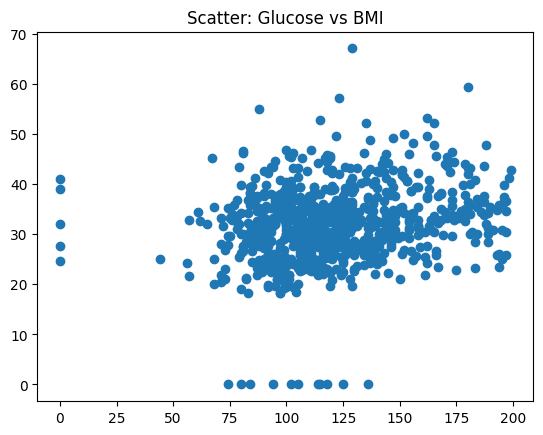

In [2]:
plt.figure()
plt.scatter(df['Glucose'], df['BMI'])
plt.title('Scatter: Glucose vs BMI')
plt.savefig("screenshots/scatter.png")
plt.show()

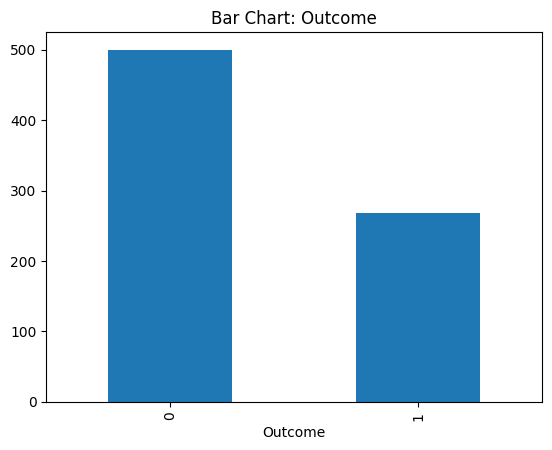

In [3]:
plt.figure()
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Bar Chart: Outcome')
plt.savefig("screenshots/bar.png")
plt.show()

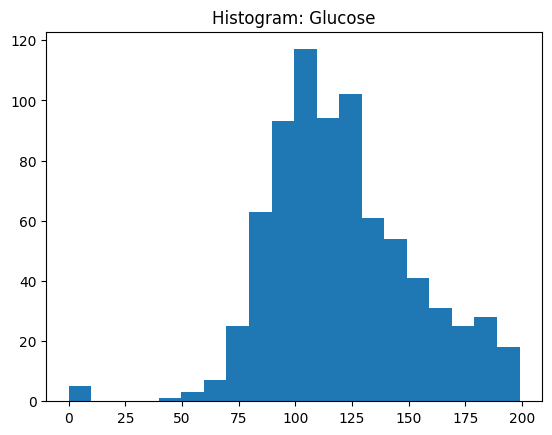

In [4]:
plt.figure()
plt.hist(df['Glucose'], bins=20)
plt.title('Histogram: Glucose')
plt.savefig("screenshots/hist.png")
plt.show()

## Preprocessing

In [5]:
df_before = df.copy()

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

df_before.head()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


In [6]:
df_before.to_csv("screenshots/before_clean.csv", index=False)
df.to_csv("screenshots/after_clean.csv", index=False)

In [7]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_no_outliers.to_csv("screenshots/no_outliers.csv", index=False)
df_no_outliers.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
5,5,116.0,74.0,29.15342,155.548223,25.6,0.201,30,0


In [8]:
df_sample = df_no_outliers.sample(frac=0.5, random_state=1)
df_reduced = df_sample.drop(columns=['SkinThickness'])

df_reduced.to_csv("screenshots/reduced.csv", index=False)
df_reduced.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
70,2,100.000000,66.000000,90.000000,32.9,0.867,28,1
525,3,87.000000,60.000000,155.548223,21.8,0.444,21,0
435,0,141.000000,72.405184,155.548223,42.4,0.205,29,1
342,1,121.686763,68.000000,155.548223,32.0,0.389,22,0
758,1,106.000000,76.000000,155.548223,37.5,0.197,26,0


In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_reduced)

df_scaled = pd.DataFrame(scaled, columns=df_reduced.columns)

df_scaled['Age_Group'] = pd.cut(df_scaled['Age'], bins=3, labels=['Young','Middle','Old'])

df_scaled.to_csv("screenshots/scaled.csv", index=False)
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group
0,0.153846,0.366013,0.366667,0.141791,0.488372,0.706256,0.155556,1.0,Young
1,0.230769,0.281046,0.266667,0.630957,0.119601,0.322756,0.000000,0.0,Young
2,0.000000,0.633987,0.473420,0.630957,0.803987,0.106074,0.177778,1.0,Young
3,0.076923,0.507757,0.400000,0.630957,0.458472,0.272892,0.022222,0.0,Young
4,0.076923,0.405229,0.533333,0.630957,0.641196,0.098821,0.111111,0.0,Young


## Statistical Analysis

In [10]:
info = df_scaled.info()
desc = df_scaled.describe()
print(desc)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               258 non-null    float64 
 1   Glucose                   258 non-null    float64 
 2   BloodPressure             258 non-null    float64 
 3   Insulin                   258 non-null    float64 
 4   BMI                       258 non-null    float64 
 5   DiabetesPedigreeFunction  258 non-null    float64 
 6   Age                       258 non-null    float64 
 7   Outcome                   258 non-null    float64 
 8   Age_Group                 258 non-null    category
dtypes: category(1), float64(8)
memory usage: 16.6 KB
       Pregnancies     Glucose  BloodPressure     Insulin         BMI  \
count   258.000000  258.000000     258.000000  258.000000  258.000000   
mean      0.321109    0.495974       0.473196    0.553070    0.442302   
std    

In [11]:
mean = df_scaled.mean(numeric_only=True)
median = df_scaled.median(numeric_only=True)
mode = df_scaled.mode().iloc[0]

print(mean, median, mode)

Pregnancies                 0.321109
Glucose                     0.495974
BloodPressure               0.473196
Insulin                     0.553070
BMI                         0.442302
DiabetesPedigreeFunction    0.278599
Age                         0.282171
Outcome                     0.356589
dtype: float64 Pregnancies                 0.230769
Glucose                     0.470588
BloodPressure               0.466667
Insulin                     0.630957
BMI                         0.445183
DiabetesPedigreeFunction    0.191296
Age                         0.177778
Outcome                     0.000000
dtype: float64 Pregnancies                      0.0
Glucose                     0.405229
BloodPressure               0.433333
Insulin                     0.630957
BMI                         0.471761
DiabetesPedigreeFunction    0.098821
Age                         0.022222
Outcome                          0.0
Age_Group                      Young
Name: 0, dtype: object


In [12]:
variance = df_scaled.var(numeric_only=True)
std = df_scaled.std(numeric_only=True)

print(variance, std)

Pregnancies                 0.069191
Glucose                     0.031979
BloodPressure               0.032436
Insulin                     0.035225
BMI                         0.033796
DiabetesPedigreeFunction    0.046867
Age                         0.068326
Outcome                     0.230326
dtype: float64 Pregnancies                 0.263041
Glucose                     0.178827
BloodPressure               0.180100
Insulin                     0.187684
BMI                         0.183836
DiabetesPedigreeFunction    0.216487
Age                         0.261392
Outcome                     0.479923
dtype: float64


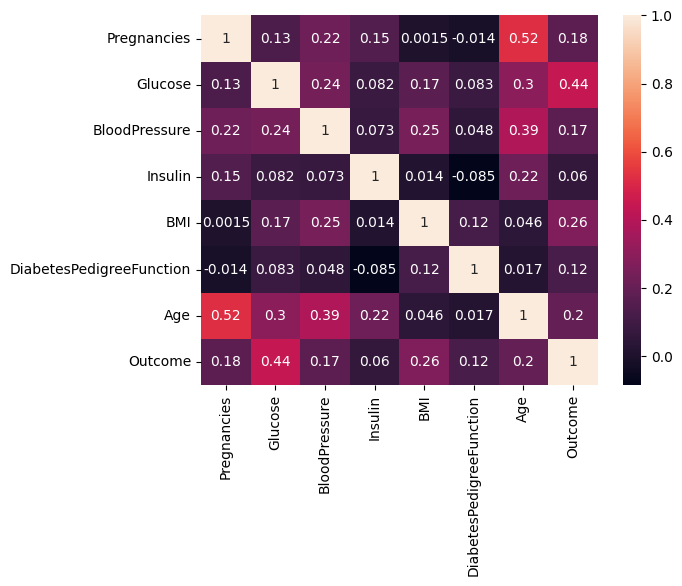

In [13]:
corr = df_scaled.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.savefig("screenshots/correlation.png")
plt.show()